# The Heston Stochastic Volatility Model

## Mathematical Formulation

The Heston model extends the Black-Scholes framework by introducing stochastic volatility. It is defined by a system of two correlated stochastic differential equations (SDEs):

### Asset Price Process:
$dS_t = \mu S_t dt + \sqrt{v_t} S_t dW_t^S$

### Variance Process:
$dv_t = \kappa (\theta - v_t) dt + \sigma_v \sqrt{v_t} dW_t^v$

With correlation:
$\text{corr}(dW_t^S, dW_t^v) = \rho dt$

## Transition from Real-World to Risk-Neutral Measures

To transition from the real-world measure ($\mathbb{P}$) to the risk-neutral measure ($\mathbb{Q}$) in the Heston model, we adjust the drifts of both the stock price ($S_t$) and variance ($v_t$) processes to ensure arbitrage-free pricing.

Under $\mathbb{Q}$, the stock drift changes from $\mu$ to $r$ (risk-free rate) 
Volatility still fluctuates, but we add a volatility risk premium (λ) to account for the fact that volatility is risky and untradable.

## Using Girsanov's Thereom to $\mathbb{P} \to \mathbb{Q}$
$\large dW^\mathbb{Q}_{S,t} = dW^\mathbb{P}_{S,t} + \alpha_S dt, \alpha_S  = \frac{\mu_\mathbb{P}-r}{\sqrt{v_t}}$

$\large dW^\mathbb{Q}_{v,t} = dW^\mathbb{P}_{v,t} + \alpha_v dt, \alpha_v  = \frac{\lambda}{\sigma^\mathbb{P}} \sqrt{v_t}$


## Heston's Stochastic Volatility Model under risk-neutral measure

$\large dS_t = r S_t dt + \sqrt{v_t} S_t dW^\mathbb{Q}_{s,t}$

$\large dv_t = \kappa^\mathbb{Q} (\theta^\mathbb{Q} - v_t)dt + \sigma \sqrt{v_t} dW^\mathbb{Q}_{v,t}$

$\large \rho^\mathbb{Q} dt = dW^\mathbb{Q}_{2,t} dW^\mathbb{Q}_{2,t} $

Where: $\large \lambda$ is the variance risk premium

$\large \rho^\mathbb{Q} = \rho, \kappa^\mathbb{Q} = \kappa+\lambda,  \theta^\mathbb{Q} = \kappa \theta/(\kappa+\lambda)$


### Parameter Definitions:
- $S_t$ = Asset price at time $t$
- $v_t$ = Instantaneous variance
- $\mu$ = Expected return (drift)
- $\kappa$ = Mean reversion speed of variance
- $\theta$ = Long-term variance (mean reversion level)
- $\sigma_v$ = Volatility of variance ("vol of vol")
- $\rho$ = Correlation between asset returns and variance changes
- $W_t^S, W_t^v$ = Wiener processes (correlated Brownian motions)

## Discretization for Simulation

Using the Euler-Maruyama scheme, we discretize the SDEs:
The scheme works as follows for an SDE of the form:

dX(t)=a(X(t))dt+b(X(t))dW(t)

where W(t) is a Wiener process (Brownian motion), and a(X(t)) and b(X(t)) are the drift and diffusion coefficients, respectively. The Euler-Maruyama approximation to the true solution X(t) is given by:

X 
n+1
​
 =X 
n
​
 +a(X 
n
​
 )Δt+b(X 
n
​
 )ΔW 
n
​
 


### Asset Price Discretization:
$S_{t+\Delta t} = S_t + \mu S_t \Delta t + \sqrt{v_t} S_t \sqrt{\Delta t} Z_1$

### Variance Discretization:
$v_{t+\Delta t} = v_t + \kappa(\theta - v_t)\Delta t + \sigma_v\sqrt{v_t}\sqrt{\Delta t}(\rho Z_1 + \sqrt{1-\rho^2}Z_2)$

Where:
- $Z_1, Z_2$ = Independent standard normal random variables
- $\Delta t$ = Time step size

## Important Properties

### 1. Feller Condition:
$2\kappa\theta > \sigma_v^2$

This condition ensures the variance process remains positive. In practice, it may be violated without causing major issues.

### 2. Variance Mean Reversion:
Expected variance follows:
$\mathbb{E}[v_t] = \theta + (v_0 - \theta)e^{-\kappa t}$

### 3. Variance of Variance:
$\text{Var}[v_t] = \frac{\sigma_v^2}{2\kappa}(1 - e^{-2\kappa t})(v_0 + \kappa\theta)$

## Implementation Considerations

### 1. Numerical Stability:
- Use full truncation scheme for variance:
  $v_{t+\Delta t} = |v_t + \kappa(\theta - \max(v_t,0))\Delta t + \sigma_v\sqrt{\max(v_t,0)}\sqrt{\Delta t}Z|$

### 2. Parameter Constraints:
- $\kappa > 0$ (positive mean reversion)
- $\theta > 0$ (positive long-term variance)
- $\sigma_v > 0$ (positive vol of vol)
- $-1 \leq \rho \leq 1$ (correlation bounds)
- $v_0 > 0$ (positive initial variance)

### 3. Monte Carlo Error Analysis:

Standard Error of Price Estimate:
$SE = \frac{\sigma_{MC}}{\sqrt{N}}$

Where:
$\sigma_{MC} = \sqrt{\frac{1}{N-1}\sum_{i=1}^N (P_i - \bar{P})^2}$

- $P_i$ = Price from $i$-th simulation
- $\bar{P}$ = Mean simulated price
- $N$ = Number of simulations

## Calibration Methods

### 1. Maximum Likelihood:
Log-likelihood function:
$\mathcal{L}(\theta) = -\frac{1}{2}\sum_{i=1}^n \left(\ln(2\pi v_i) + \frac{(r_i - \mu\Delta t)^2}{v_i\Delta t}\right)$

### 2. Root Mean Square Error:
$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (C_i^{market} - C_i^{model})^2}$

Where:
- $C_i^{market}$ = Market option price
- $C_i^{model}$ = Model option price

## Applications

1. **Option Pricing**:
   - European options
   - Path-dependent options
   - Forward-start options

2. **Risk Management**:
   - VaR calculations
   - Stress testing
   - Scenario analysis

3. **Trading Strategies**:
   - Volatility trading
   - Delta-neutral strategies
   - Correlation trading

## Parameters Selection Guidelines

Typical ranges for parameters:
- $\kappa$: [1.0, 5.0]
- $\theta$: [0.01, 0.04]
- $\sigma_v$: [0.1, 1.0]
- $\rho$: [-0.9, -0.3]
- $v_0$: [0.01, 0.05]

## Code Implementation Best Practices

1. **Variance Process**:
   - Implement square-root process carefully
   - Use absorption or reflection at zero
   - Consider full truncation scheme

2. **Time Discretization**:
   - Use at least 252 steps per year
   - Consider finer grids for high volatility
   - Implement adaptive time stepping

3. **Random Number Generation**:
   - Use antithetic variates
   - Consider quasi-random sequences
   - Implement proper correlation structure

In [21]:
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt

In [69]:

class HestonUsingMCS:
    def __init__(self, S0, v0, rho, kappa, theta, sigma, T, N, M, r, K):
        """
        Parameters for the Heston model and simulation.
        S0: Initial stock price
        v0: Initial variance
        rho: Correlation between asset returns and variance
        kappa: Rate of mean reversion for variance
        theta: Long-term mean of variance
        sigma: Volatility of volatility
        T: Time to maturity
        N: Number of time steps
        M: Number of simulations
        r: Risk-free rate
        K: Strike price
        """
        self.S0 = S0
        self.v0 = v0
        self.rho = rho
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.T = T
        self.N = N
        self.M = M
        self.r = r
        self.K = K
        self.dt = T / N
        self.S_paths = None  # To store simulated stock paths
        self.v_paths = None  # To store simulated variance paths

    def simulate_paths(self):
        """
        Simulate M paths of stock prices and variances using the Heston model.
        Stores paths in self.S_paths and self.v_paths.
        Returns terminal stock prices.
        """
        dt = self.dt
        # Correlated Brownian motions setup
        mu = np.array([0, 0])
        cov = np.array([[1, self.rho], [self.rho, 1]])

        # Initialize paths
        S = np.full((self.N + 1, self.M), self.S0)
        v = np.full((self.N + 1, self.M), self.v0)

        # Generate random numbers for all steps
        Z = np.random.multivariate_normal(mu, cov, (self.N, self.M))

        for i in range(1, self.N + 1):
            S_prev = S[i-1, :]
            v_prev = v[i-1, :]

            # Brownian increments for stock and variance
            Z_S = Z[i-1, :, 0]
            Z_v = Z[i-1, :, 1]

            # Update stock price (exact scheme for log)
            S[i, :] = S_prev * np.exp((self.r - 0.5 * v_prev) * dt + np.sqrt(v_prev * dt) * Z_S)
            
            # Update variance with full truncation to avoid negative values
            v_new = v_prev + self.kappa * (self.theta - v_prev) * dt + self.sigma * np.sqrt(v_prev * dt) * Z_v
            v[i, :] = np.maximum(v_new, 0)

        self.S_paths = S
        self.v_paths = v
        return S,v

    def price_call(self):
        """Calculate call option price and standard error using simulated paths."""
        ST = self.simulate_paths()[0]
        payoff = np.maximum(ST - self.K, 0)
        discount = np.exp(-self.r * self.T)
        price = discount * np.mean(payoff)
        stderr = discount * np.std(payoff, ddof=1) / np.sqrt(self.M)
        return price, stderr

    def price_put(self):
        """Calculate put option price and standard error using simulated paths."""
        ST = self.simulate_paths()
        payoff = np.maximum(self.K - ST, 0)
        discount = np.exp(-self.r * self.T)
        price = discount * np.mean(payoff)
        stderr = discount * np.std(payoff, ddof=1) / np.sqrt(self.M)
        return price, stderr

In [70]:
class Heston:
    def __init__(self, S0, v0, rho, kappa, theta, sigma, T, N, M, r, K):
        """
        Parameters for the Heston model and simulation.
        S0: Initial stock price
        v0: Initial variance
        rho: Correlation between asset returns and variance
        kappa: Rate of mean reversion for variance
        theta: Long-term mean of variance
        sigma: Volatility of volatility
        T: Time to maturity
        N: Number of time steps
        M: Number of simulations
        r: Risk-free rate
        K: Strike price
        """
        self.S0 = S0
        self.v0 = v0
        self.rho = rho
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.T = T
        self.N = N
        self.M = M
        self.r = r
        self.K = K
        self.dt = T / N
        self.S_paths = None  # To store simulated stock paths
        self.v_paths = None  # To store simulated variance paths

    def simulate_paths(self):
        """
        Simulate M paths of stock prices and variances using the Heston model.
        Stores paths in self.S_paths and self.v_paths.
        Returns terminal stock prices.
        """
        dt = self.dt
        # Correlated Brownian motions setup
        mu = np.array([0, 0])
        cov = np.array([[1, self.rho], [self.rho, 1]])

        # Initialize paths
        S = np.full((self.N + 1, self.M), self.S0)
        v = np.full((self.N + 1, self.M), self.v0)

        # Generate random numbers for all steps
        Z = np.random.multivariate_normal(mu, cov, (self.N, self.M))

        for i in range(1, self.N + 1):
            S_prev = S[i-1, :]
            v_prev = v[i-1, :]

            # Brownian increments for stock and variance
            Z_S = Z[i-1, :, 0]
            Z_v = Z[i-1, :, 1]

            # Update stock price (exact scheme for log)
            S[i, :] = S_prev * np.exp((self.r - 0.5 * v_prev) * dt + np.sqrt(v_prev * dt) * Z_S)
            
            # Update variance with full truncation to avoid negative values
            v_new = v_prev + self.kappa * (self.theta - v_prev) * dt + self.sigma * np.sqrt(v_prev * dt) * Z_v
            v[i, :] = np.maximum(v_new, 0)

        self.S_paths = S
        self.v_paths = v
        return S, v

    def characteristic_function(self, u, t):
        """
        Compute the characteristic function for the Heston model.
        """
        # Complex auxiliary parameters
        alpha = -0.5 * (u**2 + u * 1j)
        beta = self.kappa - self.rho * self.sigma * u * 1j
        gamma = 0.5 * self.sigma**2
        
        # Complex square root
        d = np.sqrt(beta**2 - 4 * alpha * gamma)
        
        # Auxiliary parameters
        rp = (beta + d) / (2 * gamma)
        rm = (beta - d) / (2 * gamma)
        g = rm / rp
        
        # Components of the characteristic function
        exp1 = np.exp(self.r * u * 1j * t)
        exp2 = np.exp(rm * self.v0 * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t)))
        exp3 = np.exp(self.kappa * self.theta / (self.sigma**2) * 
                     (rm * t - 2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))))
        
        return exp1 * exp2 * exp3

    def integrand(self, u, S, K, t, flag):
        """
        Integrand for the Fourier transform.
        flag: 1 for call, -1 for put
        """
        if flag == 1:  # Call option
            modified_cf = self.characteristic_function(u - 1j, t)
            numerator = np.exp(-1j * u * np.log(K)) * modified_cf
        else:  # Put option
            modified_cf = self.characteristic_function(-u - 1j, t)
            numerator = np.exp(-1j * u * np.log(K)) * modified_cf
            
        denominator = u**2 + 0.25
        return np.real(numerator / denominator)

    def price_option(self, flag=1):
        """
        Price European options using Fourier transform.
        flag: 1 for call, -1 for put
        """
        S = self.S0
        K = self.K
        t = self.T
        
        # Integration limits
        a = 0  # Lower limit
        b = 100  # Upper limit (needs to be chosen carefully)
        
        integral, _ = quad(lambda u: self.integrand(u, S, K, t, flag), a, b)
        
        if flag == 1:  # Call option
            price = S - np.sqrt(S * K) * np.exp(-self.r * t) * integral / np.pi
        else:  # Put option
            price = np.sqrt(S * K) * np.exp(-self.r * t) * integral / np.pi - S + K * np.exp(-self.r * t)
            
        return price

    def price_call(self):
        """Price a European call option using Fourier transform."""
        return self.price_option(flag=1)

    def price_put(self):
        """Price a European put option using Fourier transform."""
        return self.price_option(flag=-1)

In [66]:
# Example parameters
S0 = 100.0   # Initial stock price
v0 = 0.04    # Initial variance (e.g., 0.04 for 20% volatility)
kappa = 1.0  # Mean reversion speed
theta = 0.04 # Long-term variance
sigma = 0.2  # Volatility of volatility
rho = -0.7   # Correlation
T = 1.0      # Time to maturity
N = 100      # Time steps
M = 10000    # Simulations
r = 0.05     # Risk-free rate
K = 104      # Strike price

# Create Heston model instance
heston_model = HestonUsingMCS(S0, v0, 0.98, kappa, theta, sigma, T, N, M, r, K)



In [67]:
s,v=heston_model.simulate_paths()


In [68]:
call, call_stderr = heston_model.price_call()
print(call,call_stderr)
put, put_stderr = heston_model.price_call()
print(put ,put_stderr)


4.807734578611157 0.11266122094653781
4.703927341295362 0.11049094185668137


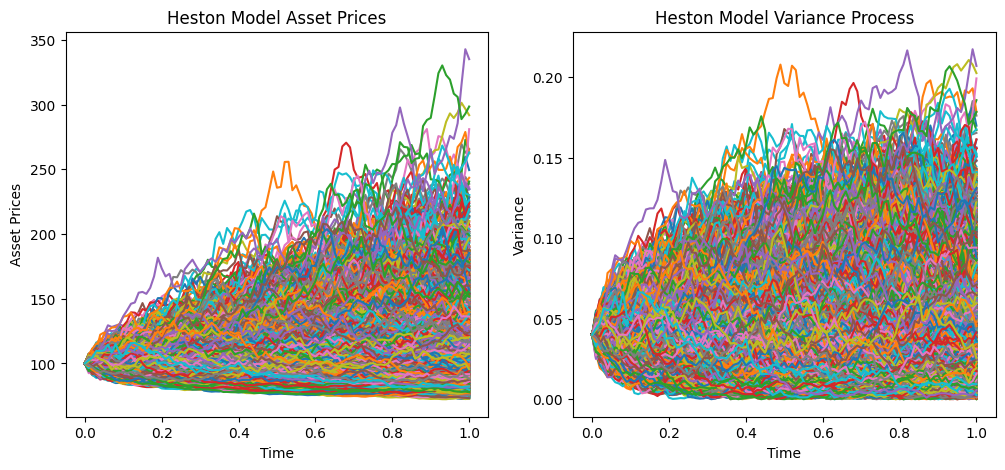

In [43]:
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(12,5))
time = np.linspace(0,T,N+1)
ax1.plot(time,s)
ax1.set_title('Heston Model Asset Prices')
ax1.set_xlabel('Time')
ax1.set_ylabel('Asset Prices')

ax2.plot(time,v)
ax2.set_title('Heston Model Variance Process')
ax2.set_xlabel('Time')
ax2.set_ylabel('Variance')

plt.show()

In [13]:
# simulate gbm process at time T
gbm = S0*np.exp( (r - theta**2/2)*T + np.sqrt(theta)*np.sqrt(T)*np.random.normal(0,1,M) )

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


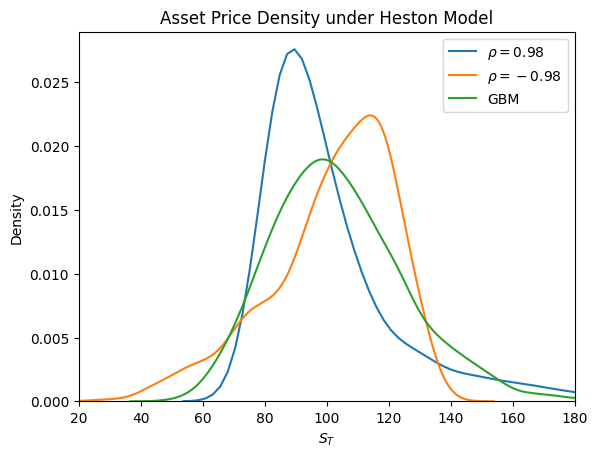

In [15]:
fig, ax = plt.subplots()
import seaborn as sns
ax = sns.kdeplot(S_p[-1], label=r"$\rho= 0.98$", ax=ax)
ax = sns.kdeplot(S_n[-1], label=r"$\rho= -0.98$", ax=ax)
ax = sns.kdeplot(gbm, label="GBM", ax=ax)

plt.title(r'Asset Price Density under Heston Model')
plt.xlim([20, 180])
plt.xlabel('$S_T$')
plt.ylabel('Density')
plt.legend()
plt.show()


In [17]:
rho = -0.7
S,v = heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M)


In [18]:
!pip install py_vollib_vectorized

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 1.2 MB/s eta 0:00:00a 0:00:01
  Created wheel for py-vollib: filename=py_vollib-1.0.1-py3-none-any.whl size=62829 sha256=39dfeea1ac38898d9a78445added3802f1973cbffad0ed9030d6a13afa994d63
  Stored in directory: /Users/utsavsharma/Library/Caches/pip/wheels/c0/5c/8f/1ed590a10a2cca3cbfa7a7caa29fb5d729b3e1f819bfda4b5e
  Created wheel for py-lets-be-rational: filename=py_lets_be_rational-1.0.1-py3-none-any.whl size=24452 sha256=e968e80ea6f5c6f09b6e1833d0ba82278eb1a8a8bcc1458e4aa419aa15d1a29a
  Stored in directory: /Users/utsavsharma/Library/Caches/pip/wheels/d9/20/b1/018f644bacb669d5cd6af600fe09ee0729ae5d75875a9f3043
Successfully built py-vollib py-lets-be-rational


In [19]:
# Set strikes and complete MC option price for different strikes
K = np.arange(20,180,2)

puts = np.array([np.exp(-r*T)*np.mean(np.maximum(k-S,0)) for k in K])
calls = np.array([np.exp(-r*T)*np.mean(np.maximum(S-k,0)) for k in K])
from py_vollib_vectorized import vectorized_implied_volatility as implied_vol

put_ivs = implied_vol(puts, S0, K, T, r, flag='p', q=0, return_as='numpy', on_error='ignore')
call_ivs = implied_vol(calls, S0, K, T, r, flag='c', q=0, return_as='numpy')

/opt/anaconda3/lib/python3.11/site-packages/py_vollib_vectorized/implied_volatility.py:75: UserWarning: Found Below Intrinsic contracts at index [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
  below_intrinsic, above_max_price = _check_below_and_above_intrinsic(K, F, flag, undiscounted_option_price, on_error)


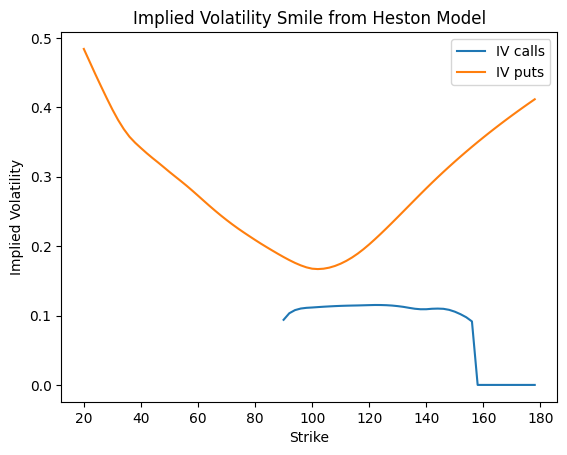

In [20]:
plt.plot(K, call_ivs, label=r'IV calls')
plt.plot(K, put_ivs, label=r'IV puts')

plt.ylabel('Implied Volatility')
plt.xlabel('Strike')

plt.title('Implied Volatility Smile from Heston Model')
plt.legend()
plt.show()